In [1]:
# ==========================================
# APP 2 ANALYTICS (FINAL — MATCH TAB3)
# ==========================================

import joblib
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
import re
import shap
# ============================
# LOAD MODEL
# ============================

package = joblib.load("model/salaryscope_3755_production_model.pkl")
app2_model = package["model"]

# ============================
# LOAD DATA (MATCH APP)
# ============================

df2 = pd.read_csv("data/ds_salaries.csv")
df2 = df2.drop_duplicates().reset_index(drop=True)
drop_cols = [c for c in ["salary", "salary_currency", "work_year"] if c in df2.columns]
df2 = df2.drop(drop_cols, axis=1)
#===============================
# --------------------------------------------------
# App 2 — Feature engineering helpers
# --------------------------------------------------
def normalize_title(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s\+]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def title_features(title):
    t = normalize_title(title)
    junior = int(any(k in t for k in ["intern", "jr", "junior", "entry"]))
    senior = int(any(k in t for k in ["senior", "sr", "staff", "lead", "principal"]))
    exec_  = int(any(k in t for k in ["head", "director", "vp", "chief"]))
    is_mgmt = int(any(k in t for k in ["manager", "head", "director", "vp", "chief", "lead"]))
    domain = "other"
    if any(k in t for k in ["analyst", "analytics"]):
        domain = "analytics"
    if any(k in t for k in ["data engineer", "etl", "pipeline"]):
        domain = "data_eng"
    if any(k in t for k in ["data scientist", "scientist"]):
        domain = "scientist"
    if any(k in t for k in ["machine learning", "ml engineer", "mlops"]):
        domain = "ml_ai"
    return junior, senior, exec_, is_mgmt, domain

def clean_feature_name(feature):
    feature = feature.replace("cat__", "").replace("num__", "")
    parts = feature.split("_")
    if feature.startswith("employee_residence_"):
        return f"Employee Residence: {parts[-1]}"
    if feature.startswith("company_location_"):
        return f"Company Location: {parts[-1]}"
    if feature.startswith("experience_level_"):
        level_map = {"EN": "Entry", "MI": "Mid", "SE": "Senior", "EX": "Executive"}
        return f"Experience Level: {level_map.get(parts[-1], parts[-1])}"
    if feature.startswith("company_size_"):
        size_map = {"S": "Small", "M": "Medium", "L": "Large"}
        return f"Company Size: {size_map.get(parts[-1], parts[-1])}"
    if feature.startswith("remote_ratio_"):
        remote_map = {"0": "On-site", "50": "Hybrid", "100": "Remote"}
        return f"Work Mode: {remote_map.get(parts[-1], parts[-1])}"
    if feature == "title_is_senior":
        return "Title Indicates Senior Role"
    if feature == "title_is_junior":
        return "Title Indicates Junior Role"
    if feature == "title_is_exec":
        return "Title Indicates Executive Role"
    if feature == "title_is_mgmt":
        return "Title Indicates Management Role"
    if feature.startswith("title_domain_"):
        domain_map = {"ml_ai": "ML / AI", "scientist": "Data Scientist",
                      "analytics": "Analytics", "data_eng": "Data Engineering", "other": "Other Domain"}
        return f"Job Domain: {domain_map.get(parts[-1], parts[-1])}"
    return feature.replace("_", " ").title()
#=================================
def prepare_app2_analytics_input(df):
    data_full = df.copy()

    drop_cols = [c for c in ["salary", "salary_currency", "work_year"] if c in data_full.columns]
    data_full = data_full.drop(drop_cols, axis=1)

    y_true = data_full["salary_in_usd"]
    X_full = data_full.drop("salary_in_usd", axis=1)

    tf_full = X_full["job_title"].apply(title_features)
    tf_full = pd.DataFrame(
        tf_full.tolist(),
        columns=[
            "title_is_junior",
            "title_is_senior",
            "title_is_exec",
            "title_is_mgmt",
            "title_domain"
        ]
    )

    X_full = pd.concat([X_full.reset_index(drop=True), tf_full.reset_index(drop=True)], axis=1)

    for col_r in ["title_is_exec", "title_is_mgmt", "title_is_junior", "title_is_senior", "title_domain"]:
        if col_r not in X_full.columns:
            X_full[col_r] = 0 if col_r != "title_domain" else "unknown"

    X_full["exp_x_domain"] = X_full["experience_level"].astype(str) + "_" + X_full["title_domain"].astype(str)
    X_full.columns = X_full.columns.astype(str)

    return X_full, y_true
# ============================
# PREPARE INPUT
# ============================

X_full, y_raw = prepare_app2_analytics_input(df2)

# ============================
# PREDICTIONS
# ============================

preds_log = app2_model.predict(X_full)
preds = np.expm1(preds_log)

residuals = y_raw - preds
residual_std = np.std(residuals)
# ============================
# XGBOOST UNCERTAINTY
# ============================

xgb_model = app2_model.named_steps["model"]
preprocessor = app2_model.named_steps["preprocessor"]

sample = X_full.sample(min(200, len(X_full)), random_state=42)
processed_sample = preprocessor.transform(sample)

booster = xgb_model.get_booster()
dmatrix = xgb.DMatrix(processed_sample)

tree_preds_log = []

for i in range(xgb_model.n_estimators):
    pred = booster.predict(dmatrix, iteration_range=(i, i + 1))
    tree_preds_log.append(pred)

tree_preds_log = np.array(tree_preds_log)
tree_preds = np.expm1(tree_preds_log)

uncertainty = tree_preds.std(axis=0)

# ============================
# SHAP (CRITICAL)
# ============================

explainer = shap.TreeExplainer(xgb_model)

sample_shap = processed_sample
shap_values = explainer.shap_values(sample_shap)

feature_names = preprocessor.get_feature_names_out()

shap_importance = np.abs(shap_values).mean(axis=0)

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": shap_importance
})

def map_group(fname):
    fname = fname.replace("cat__", "").replace("num__", "")
    if fname.startswith("employee_residence_"): return "Employee Residence"
    if fname.startswith("company_location_"): return "Company Location"
    if fname.startswith("experience_level_"): return "Experience Level"
    if fname.startswith("employment_type_"): return "Employment Type"
    if fname.startswith("company_size_"): return "Company Size"
    if fname.startswith("remote_ratio"): return "Work Mode"
    if fname.startswith("job_title_"): return "Job Title"
    if fname.startswith("title_is_"): return "Title Seniority Signals"
    if fname.startswith("title_domain_"): return "Job Domain"
    if fname.startswith("exp_x_domain_"): return "Experience × Domain Interaction"
    return "Other"

fi["group"] = fi["feature"].apply(map_group)

grouped_importance = (
    fi.groupby("group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

# Top SHAP features
shap_df = (
    pd.DataFrame({
        "Feature": [clean_feature_name(f) for f in feature_names],
        "SHAP Importance": shap_importance
    })
    .sort_values("SHAP Importance", ascending=False)
)

# ============================
# SAVE
# ============================

analytics_a2 = {
    "y_actual": y_raw.values,
    "y_pred": preds,
    "residuals": residuals.values,
    "residual_std": residual_std,
    "uncertainty": uncertainty,

    "grouped_importance": grouped_importance,
    "shap_top": shap_df,

    "pred_distribution": preds
}

with open("model/app2_analytics.pkl", "wb") as f:
    pickle.dump(analytics_a2, f)

print("APP 2 analytics saved successfully")

C:\Users\Shah\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


APP 2 analytics saved successfully


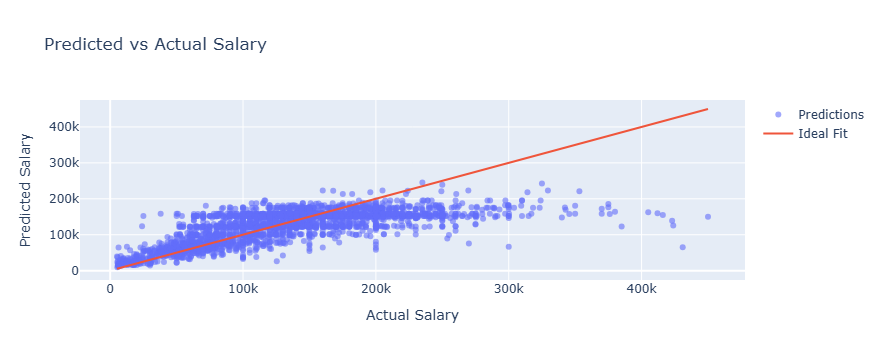

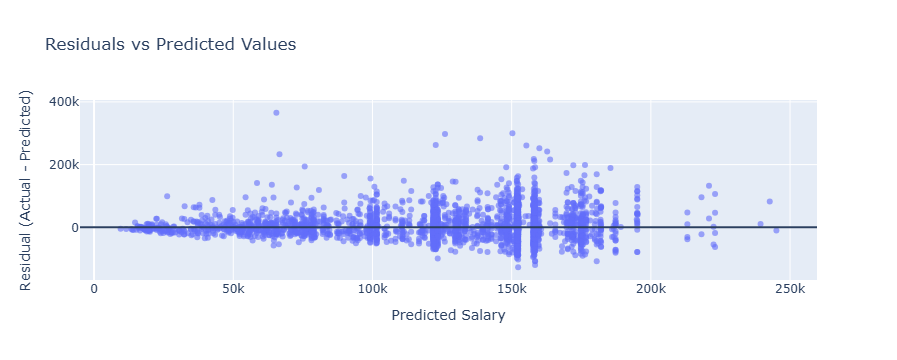

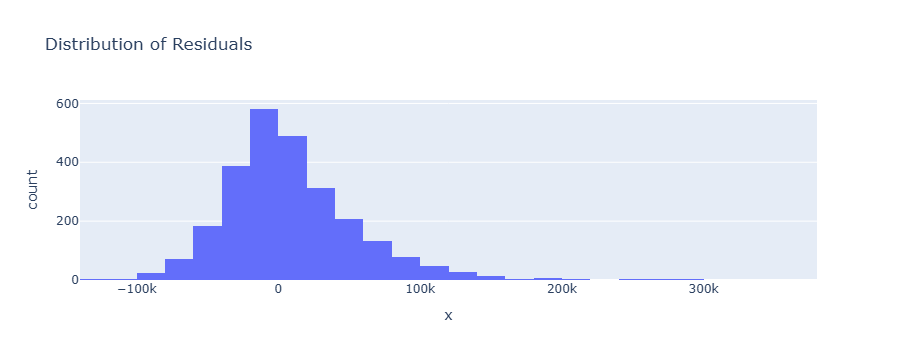

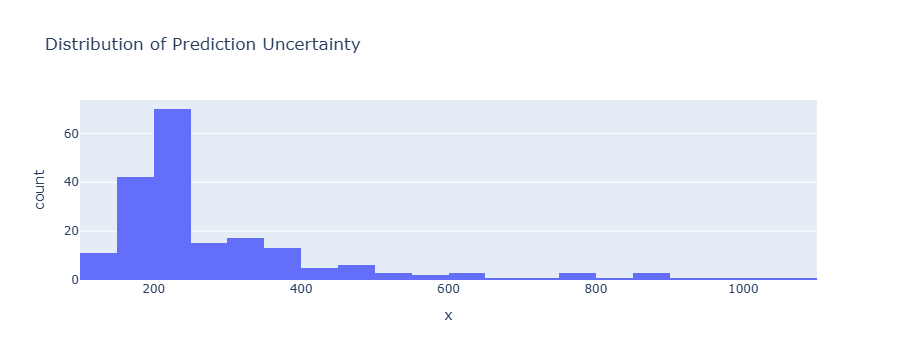

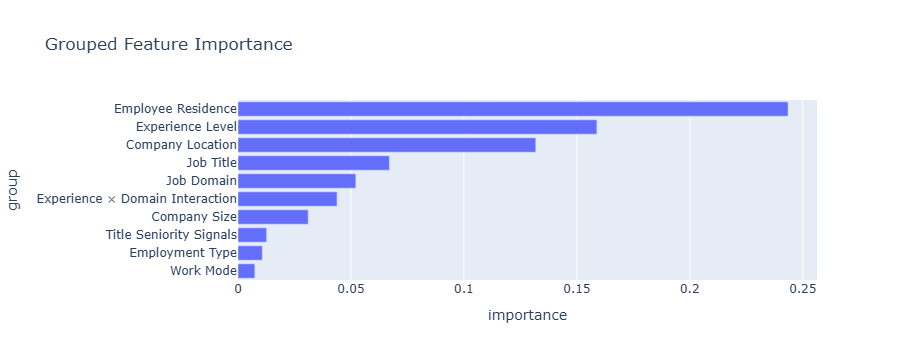

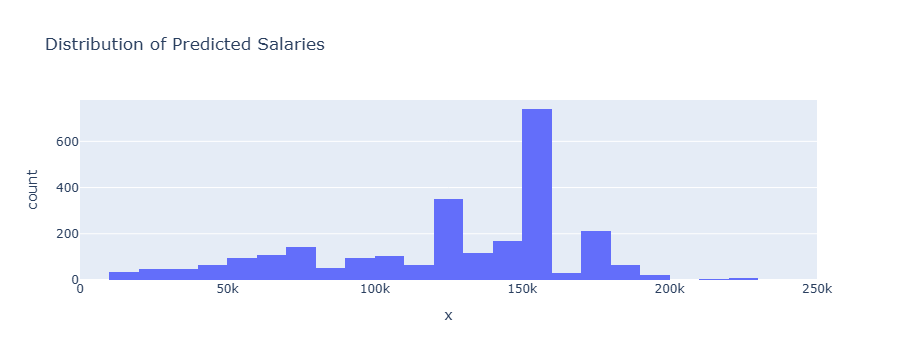

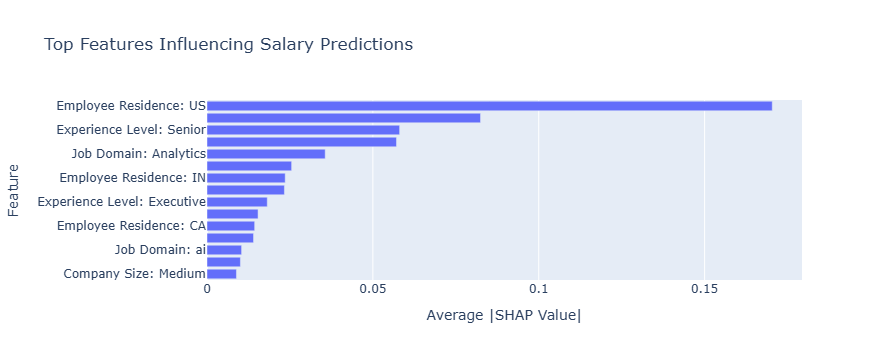

In [2]:
# ==========================================
# APP 2 — FULL TAB3 MATCH (PLOTLY FROM PICKLE)
# ==========================================

import pickle
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# ============================
# LOAD ANALYTICS
# ============================

with open("model/app2_analytics.pkl", "rb") as f:
    a2 = pickle.load(f)

y_actual = a2["y_actual"]
y_pred = a2["y_pred"]
residuals = a2["residuals"]
uncertainty = a2["uncertainty"]

grouped_importance = a2["grouped_importance"]
shap_top = a2["shap_top"]
pred_distribution = a2["pred_distribution"]

# ============================
# 1. PREDICTED VS ACTUAL
# ============================

fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x=y_actual,
    y=y_pred,
    mode="markers",
    name="Predictions",
    marker=dict(opacity=0.6)
))

min_val = min(y_actual.min(), y_pred.min())
max_val = max(y_actual.max(), y_pred.max())

fig1.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode="lines",
    name="Ideal Fit"
))

fig1.update_layout(
    title="Predicted vs Actual Salary",
    xaxis_title="Actual Salary",
    yaxis_title="Predicted Salary"
)

fig1.show()

# ============================
# 2. RESIDUAL PLOT
# ============================

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=y_pred,
    y=residuals,
    mode="markers",
    marker=dict(opacity=0.6)
))

fig2.add_hline(y=0)

fig2.update_layout(
    title="Residuals vs Predicted Values",
    xaxis_title="Predicted Salary",
    yaxis_title="Residual (Actual - Predicted)"
)

fig2.show()

# ============================
# 3. RESIDUAL DISTRIBUTION
# ============================

fig3 = px.histogram(
    x=residuals,
    nbins=30,
    title="Distribution of Residuals"
)

fig3.show()

# ============================
# 4. UNCERTAINTY DISTRIBUTION
# ============================

fig4 = px.histogram(
    x=uncertainty,
    nbins=25,
    title="Distribution of Prediction Uncertainty"
)

fig4.show()

# ============================
# 5. GROUPED FEATURE IMPORTANCE
# ============================

fig5 = px.bar(
    grouped_importance,
    x="importance",
    y="group",
    orientation="h",
    title="Grouped Feature Importance"
)

fig5.update_layout(yaxis=dict(autorange="reversed"))

fig5.show()

# ============================
# 6. PREDICTED SALARY DISTRIBUTION
# ============================

fig6 = px.histogram(
    x=pred_distribution,
    nbins=30,
    title="Distribution of Predicted Salaries"
)

fig6.show()

# ============================
# 7. TOP SHAP FEATURES
# ============================

fig7 = px.bar(
    shap_top.head(15),
    x="SHAP Importance",
    y="Feature",
    orientation="h",
    title="Top Features Influencing Salary Predictions"
)

fig7.update_layout(
    yaxis=dict(autorange="reversed"),
    xaxis_title="Average |SHAP Value|"
)

fig7.show()